# Model bazowy — pierwsze podejście

Tutaj robię pierwszy prosty model do wykrywania fraudów. Nie jest to jeszcze finalne rozwiązanie, tylko taki punkt startowy, żeby mieć z czym porównać kolejne modele.

W skrócie: wczytuję dane po preprocessingu, dzielę je na train/test, odpalam regresję logistyczną i patrzę, czy model w ogóle coś sensownie wykrywa.

## 0. Skąd biorę plik z danymi

Notebook podepnie Google Drive i spróbuje znaleźć plik w folderze `MyDrive/FinBrains/`.

Jeśli dalej go nie znajdzie, pojawi się zwykły upload pliku z komputera.

## 1. Importy

Na start wrzucam biblioteki, których potrzebuję do modelu. To są podstawowe rzeczy: pandas do danych, sklearn do modelu i metryk oraz matplotlib do wykresu macierzy pomyłek.

In [25]:
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    roc_auc_score
)

RANDOM_STATE = 42

print("importy ok")

importy ok


## 2. Wczytanie danych

Tu wczytuję przygotowaną bazę po preprocessingu.

In [26]:
import pandas as pd
from google.colab import files

print("wrzuc plik csv z baza:")
uploaded = files.upload()

nazwa_pliku = list(uploaded.keys())[0]

df = pd.read_csv(nazwa_pliku)

print("dane wczytane")
print("plik:", nazwa_pliku)
print("rozmiar bazy:", df.shape)
display(df.head())

wrzuc plik csv z baza:


Saving preproccesing_base_final_final.csv to preproccesing_base_final_final (2).csv
dane wczytane
plik: preproccesing_base_final_final (2).csv
rozmiar bazy: (10000, 26)


,Transaction_id,Timestamp,Bank_Amount,Customer_id,Customer_age,Previous_transaction,Month,Day,Week_day,Hours,...,cat_entertainment,cat_fashion,cat_fuel,cat_grocery,Cus_loc_CA,Cus_loc_FL,Cus_loc_IL,Cus_loc_NY,Cus_loc_TX,Is_fraud
0,916306a3-f7e2-4371-992a-38ab8030b680,2022-01-02 06:53:04,46.93,bef45806-a255-4cdb-a45e-012d533eee34,48,2,1,2,6,6,...,False,False,True,False,False,False,False,True,False,0
1,2d922a41-edd9-4649-81f0-c599db4b923d,2024-09-05 14:18:29,301.01,f600bad0-d244-42c4-9db3-1115214dd1c4,58,4,9,5,3,14,...,False,False,False,False,False,False,True,False,False,0
2,9d2ec6cd-f8ed-4c68-9ec7-1450c30b7fe0,2022-12-07 06:24:09,131.67,050c0996-fd20-4ce0-94ec-b1bbc1f3c229,23,2,12,7,2,6,...,True,False,False,False,False,False,False,False,True,0
3,f65f1e63-1b91-4a79-95e4-4dd825992461,2022-08-19 03:58:47,91.29,71693a5a-7103-4876-9e03-0fcb64ba3e28,69,6,8,19,4,3,...,False,True,False,False,False,True,False,False,False,0
4,e6a8161d-4fdc-4483-9b61-2c8c86567e78,2023-04-19 12:55:52,16.96,18ed5ca8-d0eb-4ccf-b4d3-fa37f15b89c7,48,0,4,19,2,12,...,False,True,False,False,False,False,False,False,True,0


## 3. Szybkie sprawdzenie danych

Zanim zrobię model, sprawdzam tylko czy mam dobrą tabelę i czy jest kolumna `Is_fraud`.

In [27]:
print("kolumny w pliku:")
for kolumna in df.columns:
    print("-", kolumna)

print("\n info o danych:")
df.info()

kolumny w pliku:
- Transaction_id
- Timestamp
- Bank_Amount
- Customer_id
- Customer_age
- Previous_transaction
- Month
- Day
- Week_day
- Hours
- Minutes
- Seconds
- device_type_desktop
- Device_type_mobile
- Device_type_tablet
- cat_electronics
- cat_entertainment
- cat_fashion
- cat_fuel
- cat_grocery
- Cus_loc_CA
- Cus_loc_FL
- Cus_loc_IL
- Cus_loc_NY
- Cus_loc_TX
- Is_fraud

 info o danych:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_id        10000 non-null  object 
 1   Timestamp             10000 non-null  object 
 2   Bank_Amount           10000 non-null  float64
 3   Customer_id           10000 non-null  object 
 4   Customer_age          10000 non-null  int64  
 5   Previous_transaction  10000 non-null  int64  
 6   Month                 10000 non-null  int64  
 7   Day                   10000 n

## 4. Target, czyli czego model ma się nauczyć

W tym projekcie model ma przewidywać kolumnę `Is_fraud`. Warto jeszcze raz sprawdzić proporcje klas, bo fraudów jest mało i to mocno wpływa na ocenę modelu.

In [28]:
KOLUMNA_CELU = "Is_fraud"

if KOLUMNA_CELU not in df.columns:
    raise ValueError(f"brakuje kolumny celu: {KOLUMNA_CELU}")

liczebnosc_klas = df[KOLUMNA_CELU].value_counts().sort_index()
procent_klas = df[KOLUMNA_CELU].value_counts(normalize=True).sort_index() * 100

podsumowanie_klas = pd.DataFrame({
    "liczba": liczebnosc_klas,
    "procent": procent_klas.round(2)
})

podsumowanie_klas.index = ["normalne (0)", "fraudy (1)"]
display(podsumowanie_klas)

print(f"liczba fraudow: {int(liczebnosc_klas.loc[1])}")
print(f"udzial fraudow w zbiorze: {procent_klas.loc[1]:.2f}%")

,liczba,procent
normalne (0),9812,98.12
fraudy (1),188,1.88


liczba fraudow: 188
udzial fraudow w zbiorze: 1.88%


## 5. Prosty wykres klas

Ten wykres nie wnosi nic bardzo odkrywczego, ale dobrze pokazuje skalę problemu. Klasa fraud jest mała, więc model łatwo może pójść w stronę przewidywania głównie transakcji normalnych.

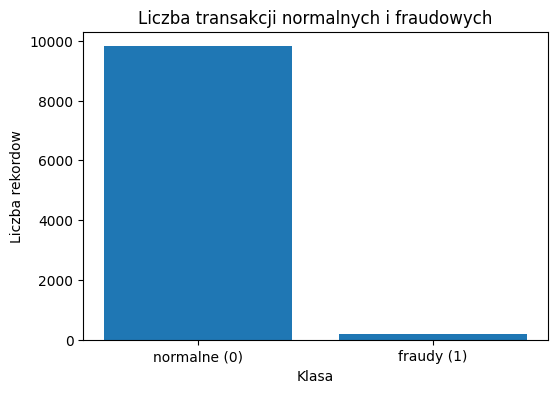

In [29]:
plt.figure(figsize=(6, 4))
plt.bar(podsumowanie_klas.index, podsumowanie_klas["liczba"])
plt.title("Liczba transakcji normalnych i fraudowych")
plt.xlabel("Klasa")
plt.ylabel("Liczba rekordow")
plt.show()

## 6. Przygotowanie X i y

Teraz rozdzielam dane na `X` i `y`. `X` to cechy transakcji, a `y` to odpowiedź, czyli czy transakcja była fraudem.

Usuwam też ID i timestamp, bo to nie są cechy, na których chcę opierać pierwszy model. Czas mamy już rozbity na osobne kolumny typu miesiąc, dzień i godzina.

In [30]:
kolumny_do_usuniecia = [
    "Transaction_id",
    "Customer_id",
    "Timestamp"
]

X = df.drop(columns=[KOLUMNA_CELU] + kolumny_do_usuniecia, errors="ignore")
y = df[KOLUMNA_CELU]

# boolki True/False zmieniam na 1/0, bo modelowi tak jest wygodniej
kolumny_bool = X.select_dtypes(include="bool").columns
X[kolumny_bool] = X[kolumny_bool].astype(int)

print("liczba cech uzytych w modelu:", X.shape[1])
print("rozmiar X:", X.shape)
print("rozmiar y:", y.shape)

print("\n cechy uzyte w modelu:")
for kolumna in X.columns:
    print("-", kolumna)

liczba cech uzytych w modelu: 22
rozmiar X: (10000, 22)
rozmiar y: (10000,)

 cechy uzyte w modelu:
- Bank_Amount
- Customer_age
- Previous_transaction
- Month
- Day
- Week_day
- Hours
- Minutes
- Seconds
- device_type_desktop
- Device_type_mobile
- Device_type_tablet
- cat_electronics
- cat_entertainment
- cat_fashion
- cat_fuel
- cat_grocery
- Cus_loc_CA
- Cus_loc_FL
- Cus_loc_IL
- Cus_loc_NY
- Cus_loc_TX


## 7. Podział na train i test

Dzielę dane na część treningową i testową. Używam `stratify=y`, żeby proporcja fraudów była podobna w obu częściach.

`random_state=42` jest po to, żeby za każdym uruchomieniem podział był taki sam. Dzięki temu łatwiej porównywać wyniki z innymi modelami.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("train:", X_train.shape)
print("test:", X_test.shape)

print("\n proporcje klas w train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\n proporcje klas w test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

train: (8000, 22)
test: (2000, 22)

 proporcje klas w train:
Is_fraud
0    98.12
1     1.88
Name: proportion, dtype: float64

 proporcje klas w test:
Is_fraud
0    98.1
1     1.9
Name: proportion, dtype: float64


## 8. Model bazowy: regresja logistyczna

Na pierwszy model biorę regresję logistyczną.

Dodałem `class_weight='balanced'`, bo fraudów jest mało. Bez tego model mógłby zbyt łatwo ignorować klasę fraud.

In [32]:
model_bazowy = Pipeline(
    steps=[
        ("skalowanie", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            solver="liblinear",
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]
)

model_bazowy.fit(X_train, y_train)

print("model wytrenowany")

model wytrenowany


## 9. Predykcje

Model jest już wytrenowany, więc sprawdzam go na zbiorze testowym. Zapisuję zarówno decyzję 0/1, jak i score fraudu, bo score później przydaje się do metryk i porównywania modeli.

In [33]:
y_pred = model_bazowy.predict(X_test)
y_pred_proba = model_bazowy.predict_proba(X_test)[:, 1]

print("predykcje gotowe")
print("liczba predykcji:", len(y_pred))

print("\n pierwsze 10 decyzji modelu:")
print(y_pred[:10])

print("\n pierwsze 10 score fraudu:")
print(np.round(y_pred_proba[:10], 4))

predykcje gotowe
liczba predykcji: 2000

 pierwsze 10 decyzji modelu:
[0 0 0 0 1 1 1 0 1 0]

 pierwsze 10 score fraudu:
[0.4232 0.475  0.4256 0.3775 0.5414 0.5402 0.5163 0.4416 0.5323 0.4315]


## 10. Ocena modelu

Tutaj patrzę na metryki. Nie opieram się tylko na accuracy, bo przy fraudach to może być mylące.

Najbardziej interesuje mnie klasa `1`, czyli fraud: ile fraudów model złapał i ile zrobił przy tym fałszywych alarmów.

In [34]:
print("=== raport klasyfikacji ===")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

macierz_pomylek = confusion_matrix(y_test, y_pred)
print("=== macierz pomylek ===")
print(macierz_pomylek)

pr_auc = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== metryki auc ===")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

=== raport klasyfikacji ===
              precision    recall  f1-score   support

           0     0.9863    0.5520    0.7078      1962
           1     0.0255    0.6053    0.0489        38

    accuracy                         0.5530      2000
   macro avg     0.5059    0.5786    0.3784      2000
weighted avg     0.9681    0.5530    0.6953      2000

=== macierz pomylek ===
[[1083  879]
 [  15   23]]
=== metryki auc ===
PR-AUC: 0.0213
ROC-AUC: 0.5635


## 11. Macierz pomyłek na wykresie

To jest ta sama macierz pomyłek, tylko w formie obrazka. Łatwiej wtedy zobaczyć, czy model bardziej przepuszcza fraudy, czy robi dużo false positive.

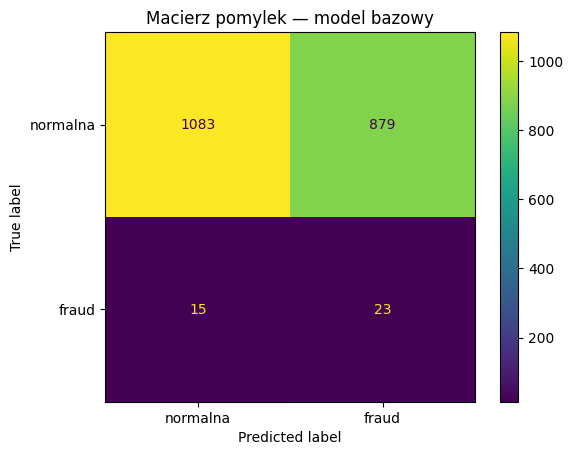

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["normalna", "fraud"]
)

plt.title("Macierz pomylek — model bazowy")
plt.show()

## 12. Wniosek roboczy

Pierwszy model bazowy jest zrobiony i działa od początku do końca: dane są wczytane, model jest wytrenowany, są predykcje i metryki.

Na tym etapie nie traktuję go jako finalnego rozwiązania. To raczej punkt odniesienia — jeśli kolejne modele, np. Decision Tree albo Random Forest, dadzą lepsze wyniki, będziemy mieli z czym je porównać.